# Peak-season LPJ-GUESS FPC anomaly → CLM `PCT_NAT_PFT`

This notebook implements the complete workflow:

1. load and validate monthly LPJ-GUESS FPC and LAI climatologies;
2. aggregate LPJ-GUESS PFTs to CLM target groups **within each month**;
3. calculate cellwise peak-season FPC and LAI at the FPC-peak month;
4. calculate `future peak − historical peak` FPC anomalies;
5. rerun the area-expansion versus saturation-consistent densification diagnostic;
6. conservatively regrid the anomaly to the CLM surfdata grid;
7. apply a closed, constrained anomaly to `PCT_NAT_PFT` and write a new file.

The future monthly files can be explored immediately. Historical-dependent
cells skip cleanly until the corresponding historical monthly files are added.

> Peak-season FPC reduces the leaf-off bias of annual-mean FPC, but it remains
> an area proxy rather than a direct measurement of crown or occupied area.


## 1 · Configuration

Edit the paths and verify the zero-based CLM PFT indices before writing a
surfdata file. The expected historical filenames follow Jing's README.


In [2]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 11,
    "axes.titlesize": 12,
})

from matplotlib.lines import Line2D
from pathlib import Path
import re

FIGURE_DIR = Path("../fpc-to-pft-analysis-figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

"""
# Start a clean notebook execution.
plt.close("all")

# Keep figures open after notebook cells display them.
ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("config", "InlineBackend.close_figures = False")
"""

DATA_DIR = Path("/nird/datapeak/NS9188K/adelez/BRL-FRST-XPSN/data/edit-surfdata/LPJ-GUESS")

FPC_FUTURE = DATA_DIR / "mfpc_pft_avg_2070_2100_monthly_mean.out"
LAI_FUTURE = DATA_DIR / "mlai_pft_avg_2070_2100_monthly_mean.out"
FPC_HISTORICAL = DATA_DIR / "mfpc_pft_avg_1971_2000_monthly_mean.out"
LAI_HISTORICAL = DATA_DIR / "mlai_pft_avg_1971_2000_monthly_mean.out"

# Optional step 6–7 inputs. Leave as None until ready to write surfdata.
SURFDATA_INPUT = None   # e.g. Path("surfdata_1.9x2.5_78pfts.nc")
SURFDATA_OUTPUT = Path("surfdata_peak_fpc_anomaly.nc")

LPJ_NATURAL = [
    "BNE", "BINE", "BNS", "TeNE", "TeBE", "IBS", "TeBS", "C3G",
    "HSE", "HSS", "LSE", "LSS", "GRT", "EPDS", "SPDS", "CLM",
]

# Aggregate first, then take the monthly maximum.
GROUPS = {
    "BoNET": ["BNE", "BINE"],
    "BoNDT (larch)": ["BNS"],
    "BoBDT": ["IBS"],
    "BoBDS shrubs": ["HSE", "HSS", "LSE", "LSS", "EPDS", "SPDS"],
    "aC3": ["C3G", "GRT"],
}

# Verify against the PFT ordering used by the target surfdata file.
# These are zero-based Python indices for the standard CLM natural-PFT ordering.
CLM_PFT_INDEX = {
    "BoNET": 2,
    "BoNDT (larch)": 3,
    "BoBDT": 8,
    "BoBDS shrubs": 11,
    "aC3": 12,
}
BARE_GROUND_INDEX = 0

# Expansion–densification diagnostic thresholds.
MIN_DFPC = 0.01
MIN_DLAI = 0.25
MAX_DFPC_DENS = 0.05
MAX_DFPC_PER_DLAI = 0.10
SATURATION_FPC = 0.50
DFPC_NOISE_TOL = 0.01

print("Future FPC:", FPC_FUTURE)
print("Future LAI:", LAI_FUTURE)
print("Historical files available:", FPC_HISTORICAL.exists() and LAI_HISTORICAL.exists())
print("Surfdata application enabled:", SURFDATA_INPUT is not None)


Future FPC: /nird/datapeak/NS9188K/adelez/BRL-FRST-XPSN/data/edit-surfdata/LPJ-GUESS/mfpc_pft_avg_2070_2100_monthly_mean.out
Future LAI: /nird/datapeak/NS9188K/adelez/BRL-FRST-XPSN/data/edit-surfdata/LPJ-GUESS/mlai_pft_avg_2070_2100_monthly_mean.out
Historical files available: True
Surfdata application enabled: False


## 2 · Robust monthly-file loader and data checks

Repeated header rows are removed before numeric conversion. The intended key
is `(longitude, latitude, month)`. `Total` is retained for a consistency check
but is not used in the analysis because its definition needs confirmation.


In [3]:
def load_monthly_field(path):
    if not path.exists():
        raise FileNotFoundError(path)

    frame = pd.read_csv(path, sep=r"\s+", low_memory=False)
    repeated_headers = frame["Lon"].astype(str).eq("Lon")
    frame = frame.loc[~repeated_headers].copy()

    required = {"Lon", "Lat", "Month", "Total", *LPJ_NATURAL}
    missing = required.difference(frame.columns)
    if missing:
        raise ValueError(f"{path}: missing columns {sorted(missing)}")

    for column in frame.columns:
        frame[column] = pd.to_numeric(frame[column], errors="raise")

    if frame.duplicated(["Lon", "Lat", "Month"]).any():
        raise ValueError(f"{path}: duplicate Lon/Lat/Month rows")
    if set(frame["Month"].unique()) != set(range(1, 13)):
        raise ValueError(f"{path}: expected calendar months 1–12")

    pft_columns = [
        column for column in frame.columns
        if column not in {"Lon", "Lat", "Month", "Total"}
    ]
    total_residual = frame["Total"] - frame[pft_columns].sum(axis=1)

    indexed = frame.set_index(["Month", "Lat", "Lon"])
    pft = indexed[pft_columns].to_xarray().to_array("pft")
    pft = pft.transpose("pft", "Month", "Lat", "Lon").rename({
        "Month": "month", "Lat": "lat", "Lon": "lon",
    })
    total = indexed["Total"].to_xarray().rename({
        "Month": "month", "Lat": "lat", "Lon": "lon",
    })

    report = {
        "file": path.name,
        "rows": len(frame),
        "grid cells": frame[["Lon", "Lat"]].drop_duplicates().shape[0],
        "repeated headers removed": int(repeated_headers.sum()),
        "duplicate keys": int(frame.duplicated(["Lon", "Lat", "Month"]).sum()),
        "total residual mean abs": float(total_residual.abs().mean()),
        "total residual max abs": float(total_residual.abs().max()),
    }
    return pft, total, report


future_fpc, future_fpc_total, fpc_future_report = load_monthly_field(FPC_FUTURE)
future_lai, future_lai_total, lai_future_report = load_monthly_field(LAI_FUTURE)
future_fpc, future_lai = xr.align(future_fpc, future_lai, join="exact")

quality_report = pd.DataFrame([fpc_future_report, lai_future_report])
display(quality_report)

if quality_report["total residual max abs"].max() > 1e-5:
    print(
        "WARNING: Total does not equal the simple sum of all PFT columns. "
        "Do not use Total until its land-unit/aggregation definition is confirmed."
    )

print("Future dimensions:", dict(future_fpc.sizes))
print("Coordinates and PFT ordering match between future FPC and LAI.")


,file,rows,grid cells,repeated headers removed,duplicate keys,total residual mean abs,total residual max abs
0,mfpc_pft_avg_2070_2100_monthly_mean.out,199428,16619,1,0,0.135690,0.985852
1,mlai_pft_avg_2070_2100_monthly_mean.out,199428,16619,1,0,0.501226,4.228732


Future dimensions: {'pft': 23, 'month': 12, 'lat': 75, 'lon': 638}
Coordinates and PFT ordering match between future FPC and LAI.


## 3 · Aggregate to CLM groups before selecting the peak month

For every cell and CLM target group:

$$
FPC_{\mathrm{peak}}=\max_m\left(\sum_{p\in g}FPC_p(m)\right).
$$

The paired diagnostic LAI is taken from the same month as peak FPC. This
preserves a physically co-temporal FPC–LAI state. The summary reports
area-weighted mean annual, JJA, and cellwise-peak FPC in their original
fractional units. Because peak timing varies spatially, the month column is
the area-weighted modal **cellwise** peak month for each CLM target group.


In [4]:
def aggregate_to_clm_groups(field):
    grouped = []
    for group, pfts in GROUPS.items():
        missing = set(pfts).difference(field.pft.values.tolist())
        if missing:
            raise ValueError(f"{group}: missing LPJ PFTs {sorted(missing)}")
        grouped.append(field.sel(pft=pfts).sum("pft", skipna=False))
    return xr.concat(grouped, dim=pd.Index(GROUPS, name="group"))


def peak_period_fields(grouped_fpc, grouped_lai):
    grouped_fpc, grouped_lai = xr.align(grouped_fpc, grouped_lai, join="exact")
    valid = np.isfinite(grouped_fpc).any("month") & np.isfinite(grouped_lai).any("month")

    peak_index = grouped_fpc.fillna(-np.inf).argmax("month")
    peak_fpc = grouped_fpc.max("month", skipna=True).where(valid)
    lai_at_fpc_peak = grouped_lai.isel(month=peak_index).where(valid)
    peak_month = (peak_index + 1).where(valid)

    return xr.Dataset({
        "peak_fpc": peak_fpc,
        "lai_at_fpc_peak": lai_at_fpc_peak,
        "peak_month": peak_month,
        "annual_mean_fpc": grouped_fpc.mean("month", skipna=True).where(valid),
        "jja_mean_fpc": grouped_fpc.sel(month=[6, 7, 8]).mean("month", skipna=True).where(valid),
    })


future_fpc_grouped = aggregate_to_clm_groups(future_fpc)
future_lai_grouped = aggregate_to_clm_groups(future_lai)
future_peak = peak_period_fields(future_fpc_grouped, future_lai_grouped)

AREA_WEIGHT = xr.DataArray(
    np.cos(np.deg2rad(future_peak.lat)),
    coords={"lat": future_peak.lat},
    dims="lat",
    name="coslat",
).broadcast_like(future_peak.peak_fpc.isel(group=0))


def weighted_sum(values, mask=None):
    if mask is None:
        mask = np.isfinite(values)
    return float((values.where(mask) * AREA_WEIGHT).sum(skipna=True))


def weighted_mean(values, mask=None):
    if mask is None:
        mask = np.isfinite(values)
    valid = mask & np.isfinite(values)
    weights = AREA_WEIGHT.where(valid)
    denominator = float(weights.sum(skipna=True))
    return (
        float((values.where(valid) * weights).sum(skipna=True)) / denominator
        if denominator > 0 else np.nan
    )


def weighted_modal_month(month_field):
    """Area-weighted mode of the cellwise peak month (1–12)."""
    month_weights = np.array([
        float(AREA_WEIGHT.where(month_field == month).sum(skipna=True))
        for month in range(1, 13)
    ])
    return int(month_weights.argmax() + 1) if month_weights.sum() > 0 else np.nan


seasonal = future_fpc_grouped.weighted(AREA_WEIGHT).mean(("lat", "lon"))

future_rows = []

for group in future_peak.group.values:
    peak = future_peak.peak_fpc.sel(group=group)
    annual = future_peak.annual_mean_fpc.sel(group=group)
    jja = future_peak.jja_mean_fpc.sel(group=group)

    peak_mean = weighted_mean(peak)
    annual_mean = weighted_mean(annual)
    jja_mean = weighted_mean(jja)

    group_seasonal = seasonal.sel(group=group)

    # Peak month of the area-weighted spatial-mean seasonal cycle
    spatial_mean_peak_month = int(
        group_seasonal.idxmax("month").item()
    )

    future_rows.append({
        "group": group,
        "annual mean FPC": annual_mean,
        "JJA mean FPC": jja_mean,
        "cellwise peak FPC": peak_mean,
        "spatial-mean peak month": spatial_mean_peak_month,
        "annual mean / peak": (
            annual_mean / peak_mean if peak_mean > 0 else np.nan
        ),
        "JJA mean / peak": (
            jja_mean / peak_mean if peak_mean > 0 else np.nan
        ),
        "peak uplift over annual mean %": (
            100 * (peak_mean / annual_mean - 1)
            if annual_mean > 0 else np.nan
        ),
    })

future_peak_comparison = (
    pd.DataFrame(future_rows)
    .set_index("group")
)

display(future_peak_comparison.round(3))


,annual mean FPC,JJA mean FPC,cellwise peak FPC,spatial-mean peak month,annual mean / peak,JJA mean / peak,peak uplift over annual mean %
group,,,,,,,
BoNET,0.266,0.266,0.266,1,1.000,1.000,0.016
BoNDT (larch),0.048,0.122,0.124,8,0.386,0.987,158.804
BoBDT,0.052,0.111,0.113,8,0.458,0.985,118.353
BoBDS shrubs,0.020,0.044,0.046,8,0.444,0.953,125.383
aC3,0.045,0.114,0.125,8,0.364,0.914,175.035


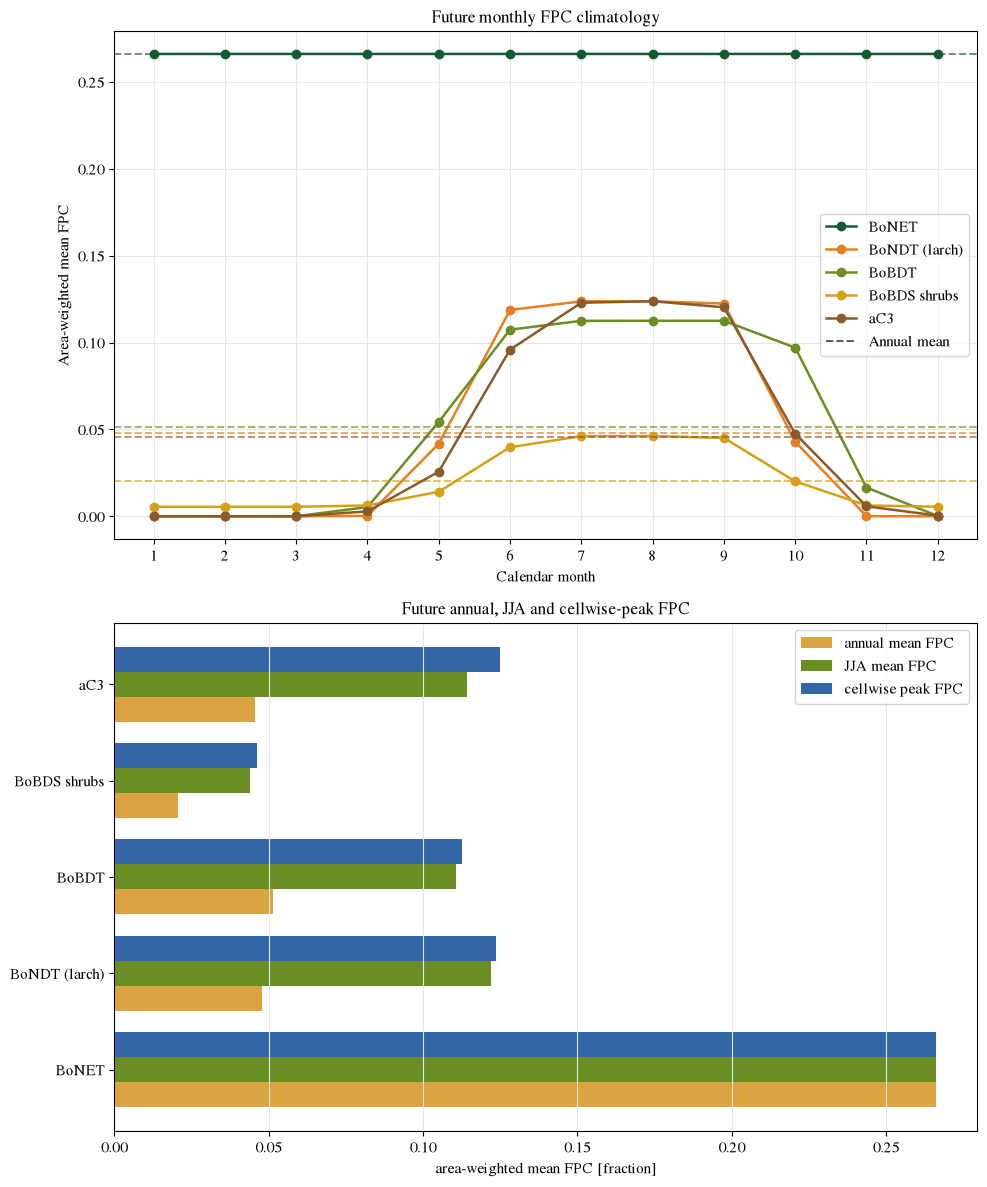

In [5]:

    

fig, axes = plt.subplots(2,1, figsize=(10, 12))
GROUP_COLORS = {
    "BoNET": "#145A32",          # dark green — needleleaf evergreen
    "BoNDT (larch)": "#E67E22",  # orange — larch
    "BoBDT": "#6B8E23",          # lighter green — broadleaf
    "BoBDS shrubs": "#D4A017",   # golden — shrubs
    "aC3": "#8B5A2B",            # brown — grass
}

seasonal = future_fpc_grouped.weighted(AREA_WEIGHT).mean(("lat", "lon"))

for group in seasonal.group.values:
    group_name = str(group)
    group_seasonal = seasonal.sel(group=group)
    color = GROUP_COLORS[group_name]

    # Monthly seasonal cycle
    axes[0].plot(
        seasonal.month,
        group_seasonal,
        color=color,
        marker="o",
        linewidth=1.8,
        label=group_name,
    )

    # Corresponding annual mean
    annual_mean = float(group_seasonal.mean("month"))

    axes[0].axhline(
        annual_mean,
        color=color,
        linestyle="--",
        linewidth=1.4,
        alpha=0.65,
    )

axes[0].set(
    title="Future monthly FPC climatology",
    xlabel="Calendar month",
    ylabel="Area-weighted mean FPC",
    xticks=range(1, 13),
)

axes[0].grid(color="0.9")
axes[0].set_axisbelow(True)

handles, labels = axes[0].get_legend_handles_labels()
handles.append(
    Line2D(
        [0], [0],
        color="0.35",
        linestyle="--",
        linewidth=1.4,
        label="Annual mean",
    )
)
axes[0].legend(handles=handles)

future_peak_comparison[[
    "annual mean FPC", "JJA mean FPC", "cellwise peak FPC"
]].plot.barh(
    ax=axes[1], color=[ "#D9A441", "#6B8E23","#3366A6"], width=0.78,
)
axes[1].set(
    title="Future annual, JJA and cellwise-peak FPC",
    xlabel="area-weighted mean FPC [fraction]",
    ylabel="",
)
axes[1].set_xlim(left=0)
axes[1].grid(axis="x", color="0.9")
axes[1].legend()

plt.tight_layout()




### Spatial distribution of the seasonal FPC correction

The following maps examine where annual averaging suppresses the representation
of peak-season foliage cover. For each PFT group, they show:

1. annual-mean FPC;
2. peak-season FPC;
3. the local seasonal difference normalized by the domain-wide annual-mean FPC:

$$
R_{PFT}(x)
=
100\,
\frac{
FPC_{\mathrm{peak},PFT}(x)-FPC_{\mathrm{annual},PFT}(x)
}{
\overline{FPC_{\mathrm{annual},PFT}}
}.
$$

Here, \(x\) denotes a grid cell, \(PFT\) denotes the PFT group, and the denominator
is one area-weighted spatial mean for the entire analysis domain—not the
annual-mean FPC of each individual cell. This avoids unstable ratios in cells
where annual FPC approaches zero while retaining the spatial pattern of the
seasonal correction.

Annual and peak-season maps use the same colour scale within each PFT group.
Cells where the PFT is effectively absent are masked. 

The overall area-weighted relative correction is reported in the third-panel title:

$$
R_g
=
100\,
\frac{
\overline{FPC_{\mathrm{peak},g}}
-
\overline{FPC_{\mathrm{annual},g}}
}{
\overline{FPC_{\mathrm{annual},g}}
}.
$$

Common normalized-correction scale: 0–10.5% (99.5th percentile)


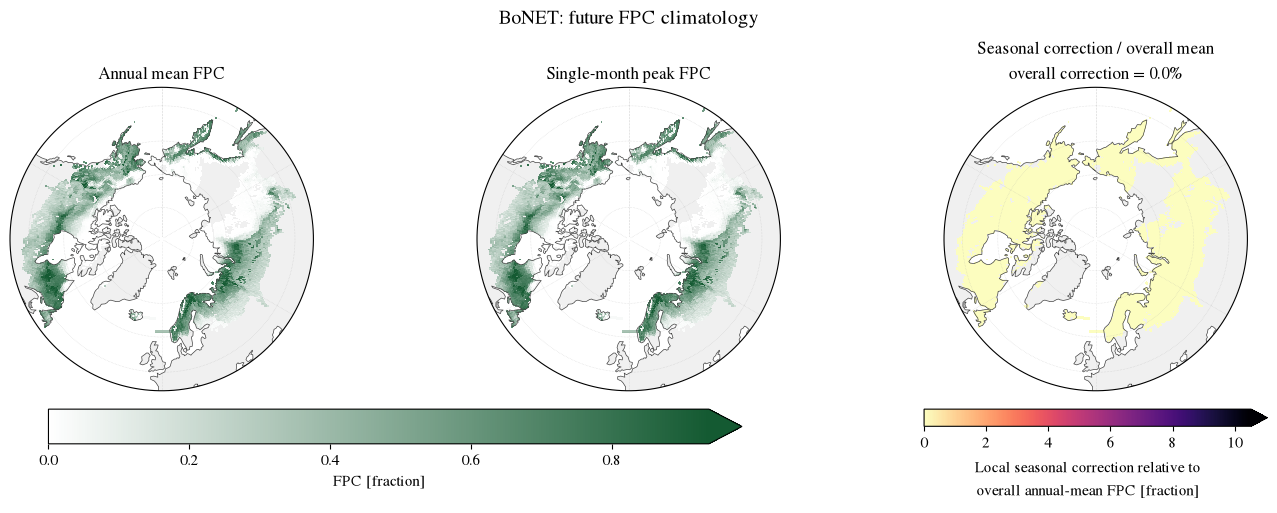

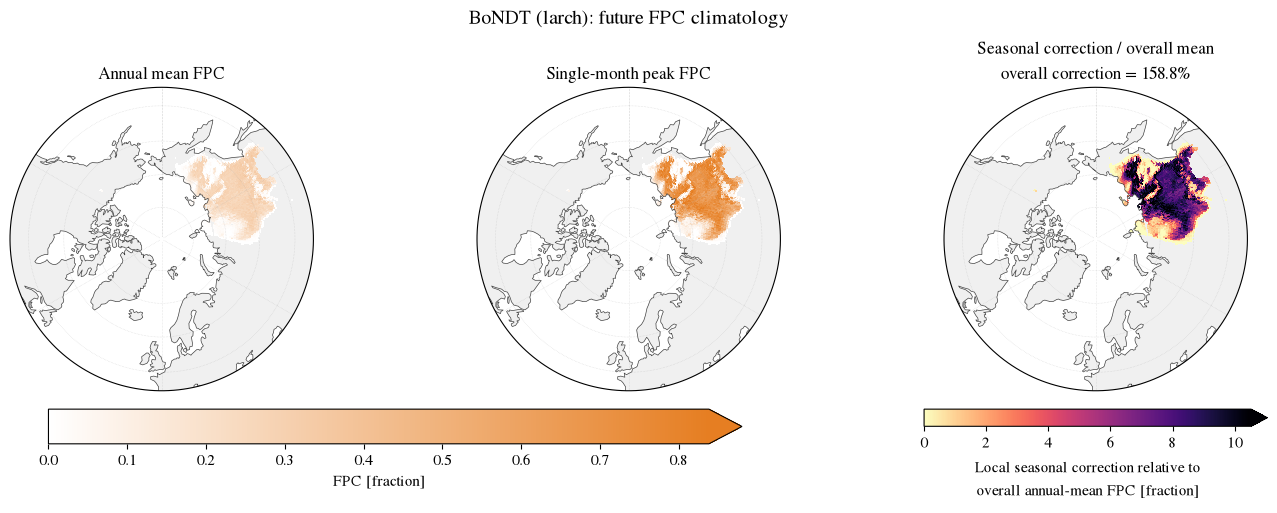

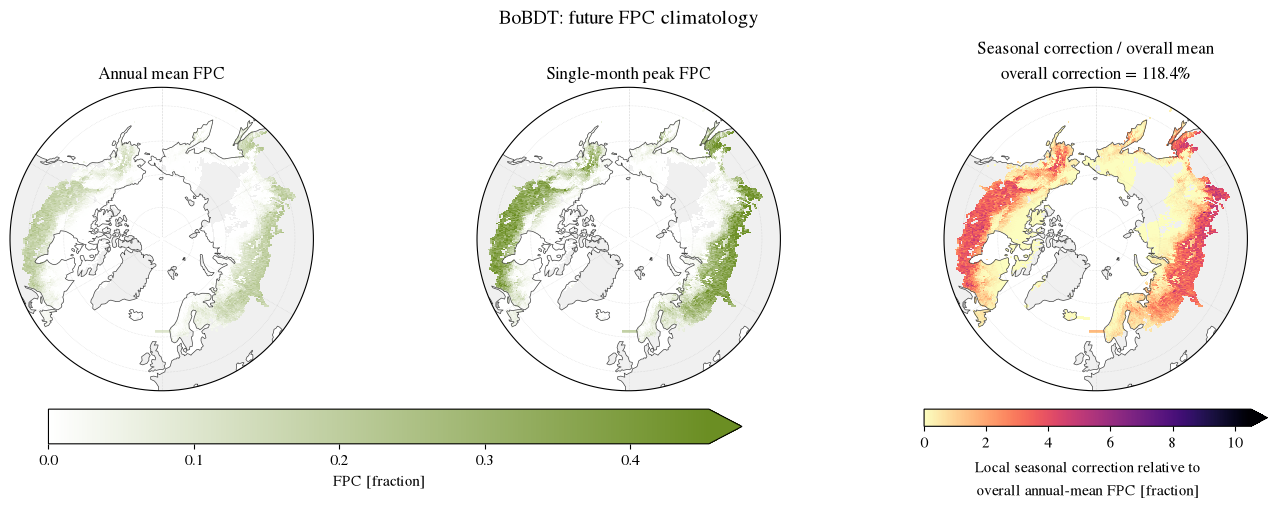

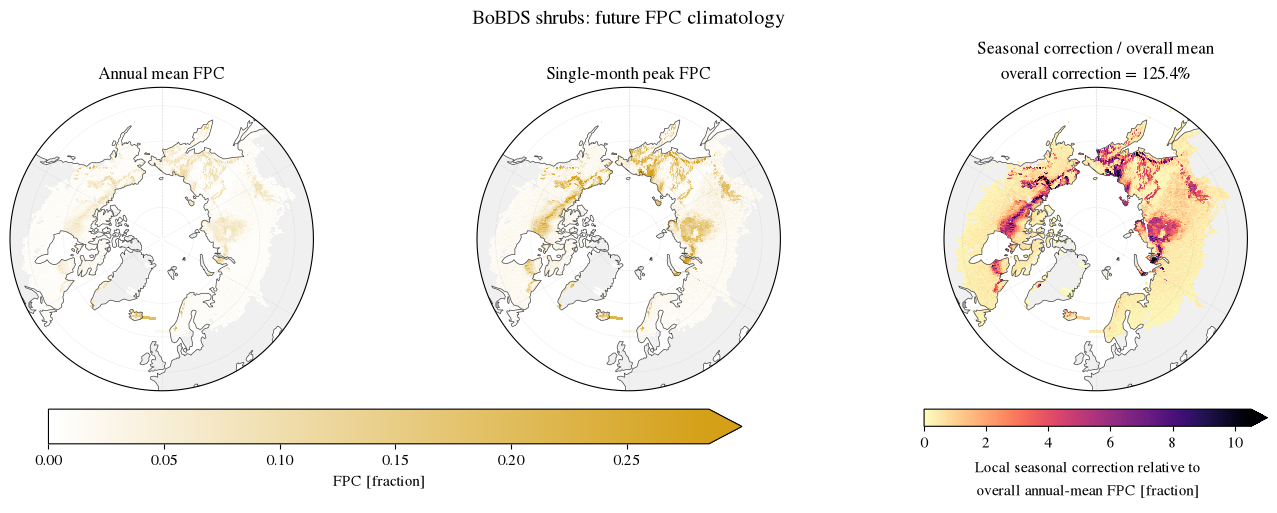

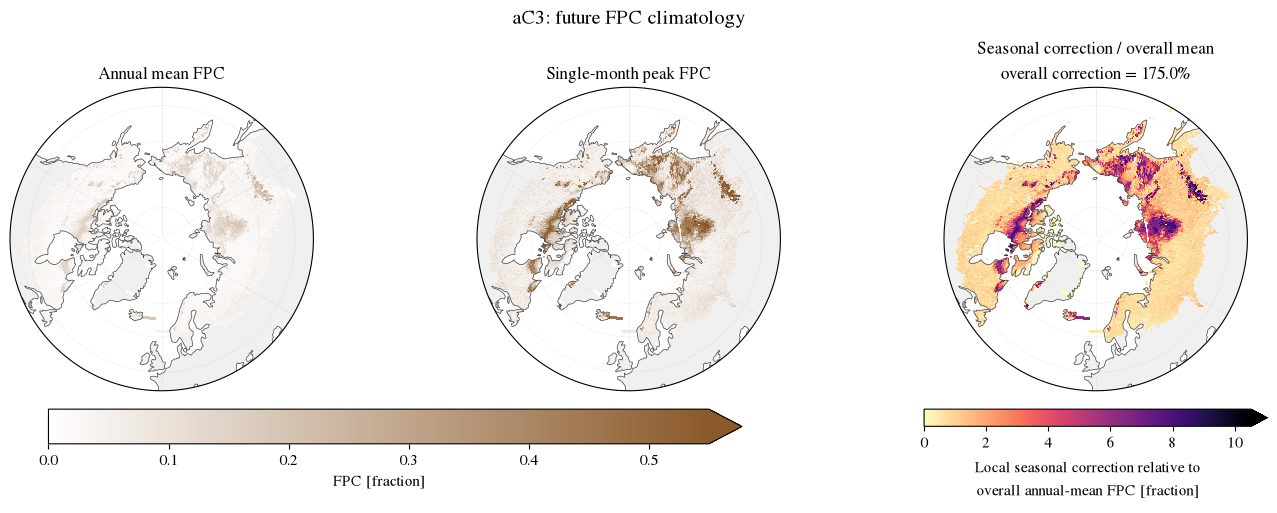

In [6]:
#plt.close("all")
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.path as mpath
from matplotlib.colors import LinearSegmentedColormap, Normalize

PEAK_FIELD = "peak3_fpc" if "peak3_fpc" in future_peak else "peak_fpc"
PEAK_LABEL = "Three-month peak" if PEAK_FIELD == "peak3_fpc" else "Single-month peak"

MAP_EXTENT = [-180, 180, 45, 90]
PRESENCE_THRESHOLD = 1e-6
SCALE_PERCENTILE = 99.5


def robust_upper(field, percentile=SCALE_PERCENTILE):
    values = field.values
    values = values[np.isfinite(values)]
    return max(float(np.percentile(values, percentile)), 1e-6)


def configure_arctic_axis(ax):
    ax.set_extent(MAP_EXTENT, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor="0.94", zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=0)
    ax.coastlines(linewidth=0.5, color="0.25")
    ax.gridlines(
        crs=ccrs.PlateCarree(),
        linewidth=0.4,
        color="0.65",
        alpha=0.5,
        linestyle=":",
    )

    theta = np.linspace(0, 2 * np.pi, 200)
    circle = np.column_stack([np.sin(theta), np.cos(theta)]) * 0.5 + 0.5
    ax.set_boundary(mpath.Path(circle), transform=ax.transAxes)


# Prepare the fields first so all normalized-correction maps can share one scale.
map_fields = {}

for group in future_peak.group.values:
    group_name = str(group)

    annual_raw = future_peak.annual_mean_fpc.sel(group=group)
    peak_raw = future_peak[PEAK_FIELD].sel(group=group)

    active = (
        np.isfinite(annual_raw)
        & np.isfinite(peak_raw)
        & (peak_raw > PRESENCE_THRESHOLD)
    )

    # Overall means use the complete analysis domain, consistent with the table.
    overall_annual = weighted_mean(annual_raw)
    overall_peak = weighted_mean(peak_raw)

    overall_relative_correction = (
        100 * (overall_peak - overall_annual) / overall_annual
        if overall_annual > 0 else np.nan
    )

    annual = annual_raw.where(active)
    peak = peak_raw.where(active)

    # Spatially varying numerator, one PFT-level denominator.
    normalized_correction = (
        (peak_raw - annual_raw).clip(min=0) / overall_annual
    ).where(active)

    map_fields[group_name] = {
        "annual": annual,
        "peak": peak,
        "normalized_correction": normalized_correction,
        "overall_relative_correction": overall_relative_correction,
    }


# Common scale for all normalized-correction maps.
all_normalized_values = np.concatenate([
    fields["normalized_correction"].values[
        np.isfinite(fields["normalized_correction"].values)
    ]
    for fields in map_fields.values()
])

NORMALIZED_VMAX = float(
    np.percentile(all_normalized_values, SCALE_PERCENTILE)
)

print(
    f"Common normalized-correction scale: 0–{NORMALIZED_VMAX:.1f}% "
    f"({SCALE_PERCENTILE}th percentile)"
)


def plot_future_fpc_maps(group_name):
    fields = map_fields[group_name]
    annual = fields["annual"]
    peak = fields["peak"]
    normalized_correction = fields["normalized_correction"]
    overall_correction = fields["overall_relative_correction"]

    absolute_upper = robust_upper(xr.concat([annual, peak], dim="metric"))
    absolute_norm = Normalize(vmin=0, vmax=absolute_upper)
    correction_norm = Normalize(vmin=0, vmax=NORMALIZED_VMAX)

    group_cmap = LinearSegmentedColormap.from_list(
        f"{group_name}_fpc",
        ["#FFFFFF", GROUP_COLORS[group_name]],
    )

    projection = ccrs.NorthPolarStereo(central_longitude=0)
    fig, axes = plt.subplots(
        1, 3, figsize=(14, 5),
        subplot_kw={"projection": projection},
        layout="constrained",
    )

    plot_fields = [annual, peak, normalized_correction]
    titles = [
        "Annual mean FPC",
        f"{PEAK_LABEL} FPC",
        "Seasonal correction / overall mean\n"
        f"overall correction = {overall_correction:.1f}%",
    ]

    images = []

    for index, (ax, field, title) in enumerate(zip(axes, plot_fields, titles)):
        configure_arctic_axis(ax)

        image = ax.pcolormesh(
            field.lon,
            field.lat,
            field,
            transform=ccrs.PlateCarree(),
            shading="auto",
            cmap=group_cmap if index < 2 else "magma_r",
            norm=absolute_norm if index < 2 else correction_norm,
            rasterized=True,
        )

        ax.set_title(title)
        images.append(image)

    absolute_bar = fig.colorbar(
        images[0],
        ax=axes[:2],
        orientation="horizontal",
        shrink=0.75,
        pad=0.05,
        extend="max" if SCALE_PERCENTILE < 100 else "neither",
    )
    absolute_bar.set_label("FPC [fraction]")

    correction_bar = fig.colorbar(
        images[2],
        ax=axes[2],
        orientation="horizontal",
        shrink=0.75,
        pad=0.05,
        extend="max",
    )
    correction_bar.set_label(
        "Local seasonal correction relative to\n"
        "overall annual-mean FPC [fraction]"
    )

    fig.suptitle(f"{group_name}: future FPC climatology", fontsize=14)
    plt.show()


for group_name in map_fields:
    plot_future_fpc_maps(group_name)

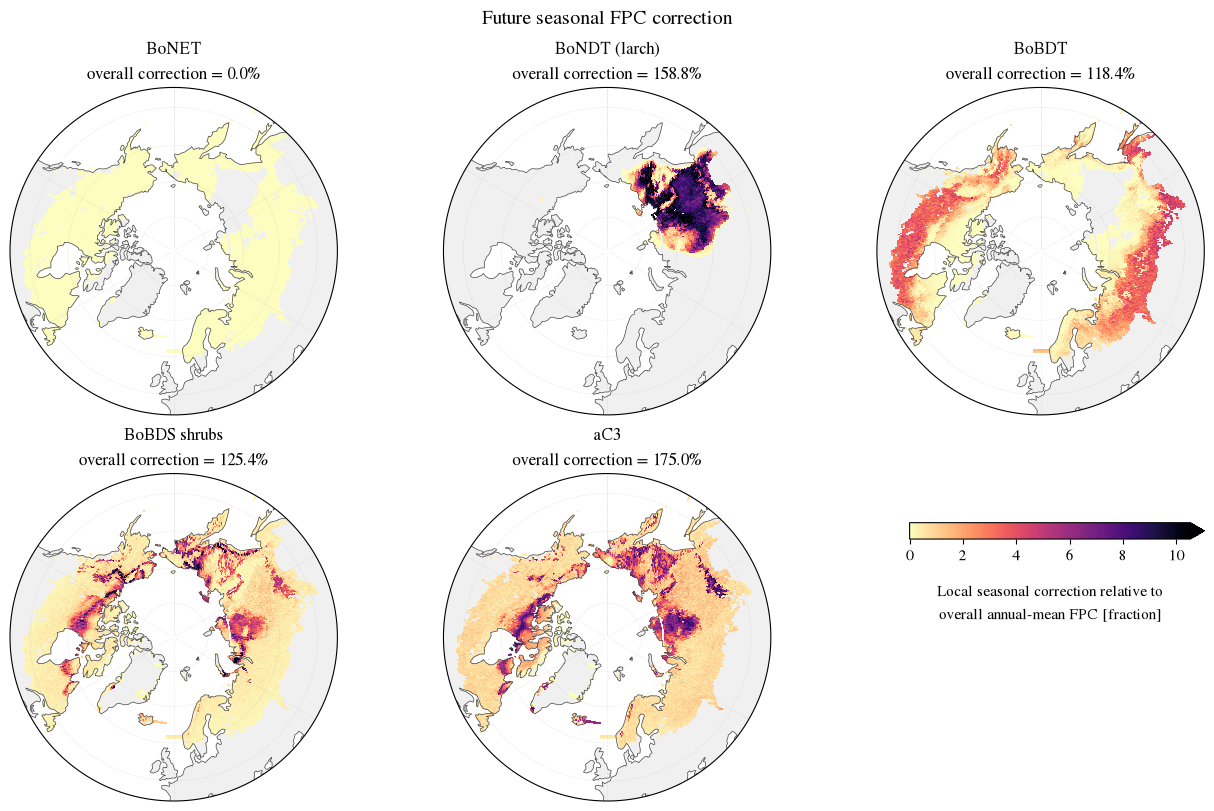

In [7]:

projection = ccrs.NorthPolarStereo(central_longitude=0)
fig, axes = plt.subplots(
    2, 3, figsize=(13, 8),
    subplot_kw={"projection": projection},
    layout="constrained",
)
axes = axes.ravel()

correction_norm = Normalize(vmin=0, vmax=NORMALIZED_VMAX)
image = None

for ax, (group_name, fields) in zip(axes[:5], map_fields.items()):
    correction = fields["normalized_correction"]
    overall = fields["overall_relative_correction"]

    configure_arctic_axis(ax)

    image = ax.pcolormesh(
        correction.lon,
        correction.lat,
        correction,
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap="magma_r",
        norm=correction_norm,
        rasterized=True,
    )

    ax.set_title(
        f"{group_name}\n"
        f"overall correction = {overall:.1f}%"
    )

# Use the sixth panel for the shared colour bar.
colorbar_panel = axes[5]
colorbar_panel.set_axis_off()

colorbar_axis = colorbar_panel.inset_axes([0.1, 0.8, 0.9, 0.05]) #[left, bottom, width, height]

colorbar = fig.colorbar(
    image,
    cax=colorbar_axis,
    orientation="horizontal",
    extend="max",
)

colorbar.set_label(#r"$FPC_{\mathrm{peak}}-FPC_{\mathrm{annual}}$""\n normalized to overall annual mean",
            "Local seasonal correction relative to\n"
        "overall annual-mean FPC [fraction]",
    labelpad=12,
)

fig.suptitle(
    "Future seasonal FPC correction",
    fontsize=14,
)

plt.show()

### Preliminary evidence from the future climatology

The monthly climatology provides clear evidence that annual-mean FPC introduces a **strong
leaf-off-season dilution.**

It also shows that the inferred peak is a broad summer feature rather than an isolated
single-month spike: **JJA FPC is already very close to peak-season FPC**. A
three-month peak-season mean therefore provides a more robust representation
than a single-month maximum while retaining the deciduous-season correction.

## 4 · Load historical monthly climatologies and construct the peak anomaly

The anomaly is calculated as the difference between the two period-specific
peaks—not as the maximum monthly future-minus-historical difference:

$$
\Delta FPC_{\mathrm{peak}} = FPC_{\mathrm{peak,future}}
- FPC_{\mathrm{peak,historical}}.
$$


In [8]:
historical_available = FPC_HISTORICAL.exists() and LAI_HISTORICAL.exists()

historical_fpc = historical_lai = historical_peak = peak_change = None

if historical_available:
    historical_fpc, historical_fpc_total, fpc_historical_report = load_monthly_field(FPC_HISTORICAL)
    historical_lai, historical_lai_total, lai_historical_report = load_monthly_field(LAI_HISTORICAL)

    historical_fpc, historical_lai, future_fpc_aligned, future_lai_aligned = xr.align(
        historical_fpc, historical_lai, future_fpc, future_lai, join="exact"
    )

    historical_peak = peak_period_fields(
        aggregate_to_clm_groups(historical_fpc),
        aggregate_to_clm_groups(historical_lai),
    )
    future_peak = peak_period_fields(
        aggregate_to_clm_groups(future_fpc_aligned),
        aggregate_to_clm_groups(future_lai_aligned),
    )

    peak_change = xr.Dataset({
        "dFPC_peak": future_peak.peak_fpc - historical_peak.peak_fpc,
        "dLAI_at_FPC_peak": (
            future_peak.lai_at_fpc_peak - historical_peak.lai_at_fpc_peak
        ),
        "historical_peak_fpc": historical_peak.peak_fpc,
        "future_peak_fpc": future_peak.peak_fpc,
        "historical_peak_month": historical_peak.peak_month,
        "future_peak_month": future_peak.peak_month,
    })

    print("Historical and future grids match exactly.")
    display(pd.DataFrame([fpc_historical_report, lai_historical_report]))
else:
    print("Historical monthly FPC/LAI files are not present; anomaly cells are skipped.")
    print("Expected:", FPC_HISTORICAL.name, "and", LAI_HISTORICAL.name)


MergeError: conflicting values for variable 'month' on objects to be combined. You can skip this check by specifying compat='override'.

## 5 · Expansion–densification diagnostic using peak-period fields

“Densification” here means a response consistent with FPC saturation: material
peak-period LAI gain, little absolute and relative FPC response, and already
high peak FPC. All other meaningful positive peak-FPC changes are retained as
an area-expansion signal. This remains a diagnostic rather than an exact
physical decomposition.


In [ ]:
def classify_peak_change(ds):
    fh = ds.historical_peak_fpc
    ff = ds.future_peak_fpc
    dF = ds.dFPC_peak
    dL = ds.dLAI_at_FPC_peak
    valid = np.isfinite(fh) & np.isfinite(ff) & np.isfinite(dF) & np.isfinite(dL)
    max_fpc = xr.concat([fh, ff], dim="period").max("period", skipna=False)
    response = xr.where(dL > 0, dF.clip(min=0) / dL, np.nan)

    densification = (
        valid
        & (dL >= MIN_DLAI)
        & (dF >= -DFPC_NOISE_TOL)
        & (dF <= MAX_DFPC_DENS)
        & (response <= MAX_DFPC_PER_DLAI)
        & (max_fpc >= SATURATION_FPC)
    )
    expansion = valid & (dF > MIN_DFPC) & ~densification
    other = valid & ~expansion & ~densification

    return ds.assign(
        response=response,
        valid=valid,
        expansion=expansion,
        densification=densification,
        other=other,
    )


peak_diagnostic = diagnostic_summary = None

if peak_change is not None:
    peak_diagnostic = classify_peak_change(peak_change)
    rows = []

    for group in peak_diagnostic.group.values:
        ds = peak_diagnostic.sel(group=group)
        positive_fpc = ds.valid & (ds.dFPC_peak > MIN_DFPC)
        material_lai = ds.valid & (ds.dLAI_at_FPC_peak >= MIN_DLAI)

        fpc_total = weighted_sum(ds.dFPC_peak, positive_fpc)
        lai_total = weighted_sum(ds.dLAI_at_FPC_peak, material_lai)

        rows.append({
            "group": group,
            "+dFPC: expansion %": 100 * weighted_sum(
                ds.dFPC_peak, positive_fpc & ds.expansion
            ) / fpc_total if fpc_total > 0 else np.nan,
            "+dFPC: densification %": 100 * weighted_sum(
                ds.dFPC_peak, positive_fpc & ds.densification
            ) / fpc_total if fpc_total > 0 else np.nan,
            "+dLAI: expansion %": 100 * weighted_sum(
                ds.dLAI_at_FPC_peak, material_lai & ds.expansion
            ) / lai_total if lai_total > 0 else np.nan,
            "+dLAI: densification %": 100 * weighted_sum(
                ds.dLAI_at_FPC_peak, material_lai & ds.densification
            ) / lai_total if lai_total > 0 else np.nan,
            "+dLAI: other %": 100 * weighted_sum(
                ds.dLAI_at_FPC_peak, material_lai & ds.other
            ) / lai_total if lai_total > 0 else np.nan,
        })

    diagnostic_summary = pd.DataFrame(rows).set_index("group")
    display(diagnostic_summary.round(1))
else:
    print("Peak-period diagnostic awaits the historical monthly files.")


In [ ]:
if diagnostic_summary is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

    diagnostic_summary[["+dFPC: expansion %", "+dFPC: densification %"]].rename(columns={
        "+dFPC: expansion %": "Area-expansion signal",
        "+dFPC: densification %": "Leaf densification",
    }).plot.barh(stacked=True, ax=axes[0], color=["#3366A6", "#D9822B"])
    axes[0].set(title="Allocation of positive peak ΔFPC", xlabel="share [%]", ylabel="", xlim=(0, 100))

    diagnostic_summary[["+dLAI: expansion %", "+dLAI: densification %", "+dLAI: other %"]].rename(columns={
        "+dLAI: expansion %": "Area-expansion signal",
        "+dLAI: densification %": "Leaf densification",
        "+dLAI: other %": "Other / ambiguous",
    }).plot.barh(
        stacked=True, ax=axes[1],
        color=["#3366A6", "#D9822B", "#B7B7B7"],
    )
    axes[1].set(title="Allocation of positive peak-period ΔLAI", xlabel="share [%]", ylabel="", xlim=(0, 100))

    for ax in axes:
        ax.grid(axis="x", color="0.9")
        ax.set_axisbelow(True)
        ax.legend(frameon=False)
    plt.tight_layout()


## 6 · Conservative regridding to the CLM surfdata grid

This step uses `xESMF` with `conservative_normed`. It runs only when both the
historical anomaly and `SURFDATA_INPUT` are available. Missing source cells
are excluded from the normalized average; target cells outside the LPJ-GUESS
domain receive zero anomaly and therefore remain unchanged.


In [ ]:
def cell_bounds(centres, clip=None):
    centres = np.asarray(centres, dtype=float)
    if centres.ndim != 1 or centres.size < 2 or np.any(np.diff(centres) <= 0):
        raise ValueError("Expected increasing one-dimensional cell centres")
    mids = 0.5 * (centres[:-1] + centres[1:])
    bounds = np.concatenate([
        [centres[0] - (mids[0] - centres[0])],
        mids,
        [centres[-1] + (centres[-1] - mids[-1])],
    ])
    if clip is not None:
        bounds = np.clip(bounds, clip[0], clip[1])
    return bounds


def prepare_source_grid(field):
    """Complete the regular 0.5° grid and use longitudes in [0, 360)."""
    lat_step = float(np.median(np.diff(field.lat.values)))
    lon_values = np.mod(field.lon.values, 360)
    field = field.assign_coords(lon=lon_values).sortby("lon")
    lon_step = float(np.median(np.diff(field.lon.values)))

    full_lat = np.arange(float(field.lat.min()), float(field.lat.max()) + lat_step / 2, lat_step)
    full_lon = np.arange(lon_step / 2, 360, lon_step)
    return field.reindex(lat=full_lat, lon=full_lon)


def surfdata_rectilinear_grid(surfdata):
    lat2d = surfdata["LATIXY"]
    lon2d = surfdata["LONGXY"]
    ydim, xdim = lat2d.dims
    lat = lat2d.isel({xdim: 0}).values
    lon = np.mod(lon2d.isel({ydim: 0}).values, 360)

    if not np.allclose(lat2d.values, lat[:, None]):
        raise ValueError("LATIXY is not rectilinear")
    if not np.allclose(np.mod(lon2d.values, 360), lon[None, :]):
        raise ValueError("LONGXY is not rectilinear")

    lat_order = np.argsort(lat)
    lon_order = np.argsort(lon)
    return lat, lon, lat_order, lon_order, ydim, xdim


delta_peak_clm = None

if peak_change is not None and SURFDATA_INPUT is not None:
    try:
        import xesmf as xe
    except ImportError as exc:
        raise ImportError("Install xESMF/ESMF in the lcc environment for conservative regridding") from exc

    surf = xr.open_dataset(SURFDATA_INPUT).load()
    source = prepare_source_grid(peak_change.dFPC_peak)
    lat, lon, lat_order, lon_order, ydim, xdim = surfdata_rectilinear_grid(surf)
    target_lat = lat[lat_order]
    target_lon = lon[lon_order]

    source_grid = xr.Dataset(coords={
        "lat": source.lat,
        "lon": source.lon,
        "lat_b": ("lat_b", cell_bounds(source.lat, clip=(-90, 90))),
        "lon_b": ("lon_b", cell_bounds(source.lon)),
    })
    target_grid = xr.Dataset(coords={
        "lat": target_lat,
        "lon": target_lon,
        "lat_b": ("lat_b", cell_bounds(target_lat, clip=(-90, 90))),
        "lon_b": ("lon_b", cell_bounds(target_lon)),
    })

    regridder = xe.Regridder(
        source_grid,
        target_grid,
        method="conservative_normed",
        periodic=True,
        ignore_degenerate=True,
        reuse_weights=False,
    )
    regridded_sorted = regridder(source, skipna=True, na_thres=1.0)

    # Restore the surfdata latitude/longitude ordering and dimensions.
    regridded = regridded_sorted.sel(lat=lat, lon=lon)
    delta_peak_clm = xr.DataArray(
        regridded.values,
        dims=("group", ydim, xdim),
        coords={
            "group": regridded.group,
            ydim: surf["PCT_NAT_PFT"].coords.get(ydim, np.arange(len(lat))),
            xdim: surf["PCT_NAT_PFT"].coords.get(xdim, np.arange(len(lon))),
        },
        name="delta_peak_fpc_clm",
    ).fillna(0)

    print("Regridded anomaly:", dict(delta_peak_clm.sizes))
else:
    print("Conservative regridding skipped: historical anomaly and/or surfdata path unavailable.")


## 7 · Apply the anomaly to `PCT_NAT_PFT`

The mapped PFT anomalies are balanced by an equal and opposite bare-ground
anomaly. If any declining category would become negative, one cell-specific
factor scales the entire closed anomaly toward zero. This preserves the
anomaly's relative composition, keeps all fractions non-negative, leaves
unmapped PFTs unchanged, and preserves the original PFT sum.


In [ ]:
def apply_closed_pct_anomaly(
    pct_nat_pft,
    delta_fraction,
    pft_index=CLM_PFT_INDEX,
    bare_index=BARE_GROUND_INDEX,
):
    pft_dim = pct_nat_pft.dims[0]
    spatial_dims = pct_nat_pft.dims[1:]
    baseline = pct_nat_pft.transpose(pft_dim, *spatial_dims).astype(float)

    if baseline.sizes[pft_dim] <= max([bare_index, *pft_index.values()]):
        raise ValueError("Configured CLM PFT index exceeds the PCT_NAT_PFT dimension")

    delta = xr.zeros_like(baseline)
    for group, index in pft_index.items():
        # LPJ FPC fractions → CLM percentage points.
        delta[{pft_dim: index}] = 100 * delta_fraction.sel(group=group)

    mapped_indices = list(pft_index.values())
    delta[{pft_dim: bare_index}] = -delta.isel({pft_dim: mapped_indices}).sum(pft_dim)

    negative = delta < 0
    allowable = xr.where(negative, baseline / (-delta), np.inf)
    scale = allowable.min(pft_dim).clip(min=0, max=1).fillna(1)
    active = np.abs(delta).max(pft_dim) > 0
    scale = xr.where(active, scale, 1)

    updated = baseline + delta * scale
    updated = updated.where(updated > -1e-10, 0)

    diagnostics = {
        "scaled cells": int(((scale < 1 - 1e-12) & active).sum()),
        "active cells": int(active.sum()),
        "minimum scale": float(scale.where(active).min(skipna=True)),
        "minimum resulting PFT %": float(updated.min(skipna=True)),
        "maximum sum error": float(
            np.abs(updated.sum(pft_dim) - baseline.sum(pft_dim)).max(skipna=True)
        ),
        "maximum change in unmapped PFTs": float(
            np.abs(
                updated.drop_isel({pft_dim: [bare_index, *mapped_indices]})
                - baseline.drop_isel({pft_dim: [bare_index, *mapped_indices]})
            ).max(skipna=True)
        ),
    }
    return updated.transpose(*pct_nat_pft.dims), scale, diagnostics


if delta_peak_clm is not None:
    # Confirm these indices against the target file before allowing the write.
    print("Configured zero-based CLM PFT indices:", CLM_PFT_INDEX)
    CONFIRM_PFT_INDICES = False  # change to True only after manual verification

    if not CONFIRM_PFT_INDICES:
        print("WRITE BLOCKED: verify CLM_PFT_INDEX, then set CONFIRM_PFT_INDICES=True.")
    else:
        updated_pct, anomaly_scale, application_report = apply_closed_pct_anomaly(
            surf["PCT_NAT_PFT"], delta_peak_clm
        )
        display(pd.Series(application_report, name="value").to_frame())

        if application_report["minimum resulting PFT %"] < -1e-8:
            raise AssertionError("Negative PCT_NAT_PFT created")
        if application_report["maximum sum error"] > 1e-6:
            raise AssertionError("PCT_NAT_PFT normalization was not preserved")
        if application_report["maximum change in unmapped PFTs"] > 1e-10:
            raise AssertionError("An unmapped PFT changed")

        surf_output = surf.copy(deep=True)
        surf_output["PCT_NAT_PFT"] = updated_pct.astype(surf["PCT_NAT_PFT"].dtype)
        surf_output.attrs["peak_fpc_anomaly_source"] = (
            f"{FPC_HISTORICAL.name}; {FPC_FUTURE.name}"
        )
        surf_output.attrs["peak_fpc_anomaly_method"] = (
            "CLM-group monthly FPC maximum; future minus historical; "
            "conservative_normed regridding; closed anomaly scaled to non-negativity"
        )
        surf_output.to_netcdf(SURFDATA_OUTPUT, format="NETCDF4_CLASSIC")
        print("Wrote:", SURFDATA_OUTPUT.resolve())
else:
    print("Surfdata application awaits historical monthly files and SURFDATA_INPUT.")


## 8 · Required checks before using the output

- Confirm with Jing how `Total` is calculated; it is not assumed to be the
  simple sum of the PFT columns.
- Confirm that both periods use the same averaging convention and comparable
  climatological windows.
- Verify every zero-based CLM PFT index against the target surfdata PFT order.
- Inspect historical and future peak-month maps for artefacts or phenological
  timing shifts.
- Compare the peak-based anomaly with JJA-based and annual-mean anomalies.
- Rerun the area-expansion/densification diagnostic and report its threshold
  sensitivity.
- Check the number and location of constrained cells and the minimum applied
  scale factor.
- Run at least a short CLM test and verify `PCT_NAT_PFT`, prognostic LAI,
  surface albedo, and BVOC emissions before launching the full experiment.


In [7]:
def safe_filename(text):
    text = re.sub(r"[^A-Za-z0-9_-]+", "_", text.strip().lower())
    return text.strip("_") or "untitled_figure"


def figure_title(fig, number):
    if fig._suptitle is not None and fig._suptitle.get_text().strip():
        return fig._suptitle.get_text()

    for ax in fig.axes:
        if ax.get_title().strip():
            return ax.get_title()

    return f"figure_{number:02d}"


figure_numbers = plt.get_fignums()

if not figure_numbers:
    print("No open Matplotlib figures found.")

else:
    saved_paths = []

    for order, figure_number in enumerate(figure_numbers, start=1):
        fig = plt.figure(figure_number)
        title = figure_title(fig, order)
        stem = f"{order:02d}_{safe_filename(title)}"

        png_path = FIGURE_DIR / f"{stem}.png"
        pdf_path = FIGURE_DIR / f"{stem}.pdf"

        fig.savefig(
            png_path,
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
        )

        fig.savefig(
            pdf_path,
            bbox_inches="tight",
            facecolor="white",
        )

        saved_paths.extend([png_path, pdf_path])

    print(
        f"Saved {len(figure_numbers)} figures as PNG and PDF "
        f"to {FIGURE_DIR.resolve()}"
    )

    for path in saved_paths:
        print(f"  {path.name}")

    plt.close("all")

Saved 7 figures as PNG and PDF to /cluster/home/adelez/BOREAL-FOREST-EXPANSION/preprocess/edit-surfdatafile/fpc-to-pft-analysis-figures
  01_future_monthly_fpc_climatology.png
  01_future_monthly_fpc_climatology.pdf
  02_bonet_future_fpc_climatology.png
  02_bonet_future_fpc_climatology.pdf
  03_bondt_larch_future_fpc_climatology.png
  03_bondt_larch_future_fpc_climatology.pdf
  04_bobdt_future_fpc_climatology.png
  04_bobdt_future_fpc_climatology.pdf
  05_bobds_shrubs_future_fpc_climatology.png
  05_bobds_shrubs_future_fpc_climatology.pdf
  06_ac3_future_fpc_climatology.png
  06_ac3_future_fpc_climatology.pdf
  07_future_seasonal_fpc_correction.png
  07_future_seasonal_fpc_correction.pdf
